In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
device = torch.device('cpu')


In [ ]:
batch_size = 128
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
class_names = train_dataset.classes


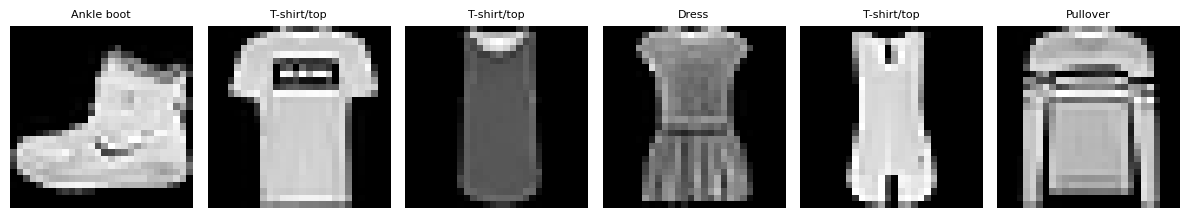

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img, lbl = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(class_names[lbl], fontsize=8)
    axes[i].axis('off')
plt.tight_layout()


In [ ]:
def multiclass_metrics_from_logits(logits, targets, num_classes=10):
    preds = torch.argmax(logits, dim=1)
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=logits.device)
    for t, p in zip(targets, preds):
        cm[t, p] += 1
    tp = torch.diag(cm).float()
    fp = cm.sum(dim=0).float() - tp
    fn = cm.sum(dim=1).float() - tp
    precision_per_class = tp / (tp + fp + 1e-12)
    recall_per_class = tp / (tp + fn + 1e-12)
    f1_per_class = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + 1e-12)
    accuracy = (tp.sum() / cm.sum().float()).item()
    precision = precision_per_class.mean().item()
    recall = recall_per_class.mean().item()
    f1 = f1_per_class.mean().item()
    return accuracy, precision, recall, f1


In [ ]:
class MlpNet(nn.Module):
    def __init__(self, activation='relu', use_dropout=True):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.activation_name = activation
        self.dropout = nn.Dropout(0.3) if use_dropout else nn.Identity()
    def act(self, x):
        if self.activation_name == 'relu':
            return F.relu(x)
        if self.activation_name == 'sigmoid':
            return torch.sigmoid(x)
        raise ValueError('Unsupported activation')
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.act(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, num_classes=10):
    model.train()
    total_loss = 0.0
    all_logits = []
    all_targets = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        all_logits.append(logits.detach())
        all_targets.append(y.detach())
    avg_loss = total_loss / len(loader.dataset)
    logits_cat = torch.cat(all_logits, dim=0)
    targets_cat = torch.cat(all_targets, dim=0)
    acc, prec, rec, f1 = multiclass_metrics_from_logits(logits_cat, targets_cat, num_classes=num_classes)
    return avg_loss, acc, prec, rec, f1
def eval_one_epoch(model, loader, criterion, num_classes=10):
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            all_logits.append(logits)
            all_targets.append(y)
    avg_loss = total_loss / len(loader.dataset)
    logits_cat = torch.cat(all_logits, dim=0)
    targets_cat = torch.cat(all_targets, dim=0)
    acc, prec, rec, f1 = multiclass_metrics_from_logits(logits_cat, targets_cat, num_classes=num_classes)
    return avg_loss, acc, prec, rec, f1


In [ ]:
epochs_mlp = 15
def run_mlp_experiment(name, activation='relu', use_dropout=True, weight_decay=0.0):
    model = MlpNet(activation=activation, use_dropout=use_dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_prec': [], 'val_prec': [],
        'train_rec': [], 'val_rec': [],
        'train_f1': [], 'val_f1': []
    }
    for epoch in range(epochs_mlp):
        tr = train_one_epoch(model, train_loader, criterion, optimizer)
        va = eval_one_epoch(model, test_loader, criterion)
        history['train_loss'].append(tr[0]); history['val_loss'].append(va[0])
        history['train_acc'].append(tr[1]); history['val_acc'].append(va[1])
        history['train_prec'].append(tr[2]); history['val_prec'].append(va[2])
        history['train_rec'].append(tr[3]); history['val_rec'].append(va[3])
        history['train_f1'].append(tr[4]); history['val_f1'].append(va[4])
        print(f"[{name}] epoch {epoch+1}/{epochs_mlp} | "
              f"train_loss={tr[0]:.4f} val_loss={va[0]:.4f} | "
              f"val_acc={va[1]:.4f} val_f1={va[4]:.4f}")
    return model, history


In [ ]:
# базовая Mlp
model_base, hist_base = run_mlp_experiment(
    name='Base: ReLU + Reg',
    activation='relu',
    use_dropout=True,
    weight_decay=1e-4
)


[Base: ReLU + Reg] epoch 1/15 | train_loss=0.6456 val_loss=0.4634 | val_acc=0.8313 val_f1=0.8275
[Base: ReLU + Reg] epoch 2/15 | train_loss=0.4332 val_loss=0.4046 | val_acc=0.8504 val_f1=0.8462
[Base: ReLU + Reg] epoch 3/15 | train_loss=0.3925 val_loss=0.3858 | val_acc=0.8616 val_f1=0.8624
[Base: ReLU + Reg] epoch 4/15 | train_loss=0.3725 val_loss=0.3743 | val_acc=0.8629 val_f1=0.8623
[Base: ReLU + Reg] epoch 5/15 | train_loss=0.3591 val_loss=0.3774 | val_acc=0.8605 val_f1=0.8566
[Base: ReLU + Reg] epoch 6/15 | train_loss=0.3470 val_loss=0.3533 | val_acc=0.8745 val_f1=0.8740
[Base: ReLU + Reg] epoch 7/15 | train_loss=0.3335 val_loss=0.3720 | val_acc=0.8641 val_f1=0.8665
[Base: ReLU + Reg] epoch 8/15 | train_loss=0.3271 val_loss=0.3505 | val_acc=0.8761 val_f1=0.8772
[Base: ReLU + Reg] epoch 9/15 | train_loss=0.3212 val_loss=0.3412 | val_acc=0.8804 val_f1=0.8796
[Base: ReLU + Reg] epoch 10/15 | train_loss=0.3125 val_loss=0.3382 | val_acc=0.8803 val_f1=0.8797
[Base: ReLU + Reg] epoch 11/1

In [ ]:
# Mlp без регуляризации
model_no_reg, hist_no_reg = run_mlp_experiment(
    name='ReLU no Reg',
    activation='relu',
    use_dropout=False,
    weight_decay=0.0
)


[ReLU no Reg] epoch 1/15 | train_loss=0.5685 val_loss=0.4527 | val_acc=0.8414 val_f1=0.8376
[ReLU no Reg] epoch 2/15 | train_loss=0.3886 val_loss=0.3997 | val_acc=0.8565 val_f1=0.8563
[ReLU no Reg] epoch 3/15 | train_loss=0.3455 val_loss=0.3872 | val_acc=0.8618 val_f1=0.8611
[ReLU no Reg] epoch 4/15 | train_loss=0.3158 val_loss=0.3566 | val_acc=0.8706 val_f1=0.8685
[ReLU no Reg] epoch 5/15 | train_loss=0.2957 val_loss=0.3361 | val_acc=0.8804 val_f1=0.8800
[ReLU no Reg] epoch 6/15 | train_loss=0.2789 val_loss=0.3327 | val_acc=0.8802 val_f1=0.8804
[ReLU no Reg] epoch 7/15 | train_loss=0.2690 val_loss=0.3333 | val_acc=0.8837 val_f1=0.8833
[ReLU no Reg] epoch 8/15 | train_loss=0.2555 val_loss=0.3339 | val_acc=0.8804 val_f1=0.8810
[ReLU no Reg] epoch 9/15 | train_loss=0.2458 val_loss=0.3316 | val_acc=0.8834 val_f1=0.8820
[ReLU no Reg] epoch 10/15 | train_loss=0.2359 val_loss=0.3389 | val_acc=0.8841 val_f1=0.8838
[ReLU no Reg] epoch 11/15 | train_loss=0.2257 val_loss=0.3223 | val_acc=0.8855 

In [ ]:
# Mlp с сигмоидой
model_sigmoid, hist_sigmoid = run_mlp_experiment(
    name='Sigmoid + Reg',
    activation='sigmoid',
    use_dropout=True,
    weight_decay=1e-4
)


[Sigmoid + Reg] epoch 1/15 | train_loss=0.9274 val_loss=0.5432 | val_acc=0.8059 val_f1=0.8026
[Sigmoid + Reg] epoch 2/15 | train_loss=0.5158 val_loss=0.4667 | val_acc=0.8317 val_f1=0.8309
[Sigmoid + Reg] epoch 3/15 | train_loss=0.4656 val_loss=0.4362 | val_acc=0.8425 val_f1=0.8422
[Sigmoid + Reg] epoch 4/15 | train_loss=0.4411 val_loss=0.4183 | val_acc=0.8491 val_f1=0.8474
[Sigmoid + Reg] epoch 5/15 | train_loss=0.4259 val_loss=0.4192 | val_acc=0.8480 val_f1=0.8483
[Sigmoid + Reg] epoch 6/15 | train_loss=0.4139 val_loss=0.4027 | val_acc=0.8532 val_f1=0.8514
[Sigmoid + Reg] epoch 7/15 | train_loss=0.4042 val_loss=0.3949 | val_acc=0.8573 val_f1=0.8548
[Sigmoid + Reg] epoch 8/15 | train_loss=0.3976 val_loss=0.3886 | val_acc=0.8571 val_f1=0.8571
[Sigmoid + Reg] epoch 9/15 | train_loss=0.3939 val_loss=0.3825 | val_acc=0.8611 val_f1=0.8593
[Sigmoid + Reg] epoch 10/15 | train_loss=0.3878 val_loss=0.3808 | val_acc=0.8587 val_f1=0.8574
[Sigmoid + Reg] epoch 11/15 | train_loss=0.3840 val_loss=0.

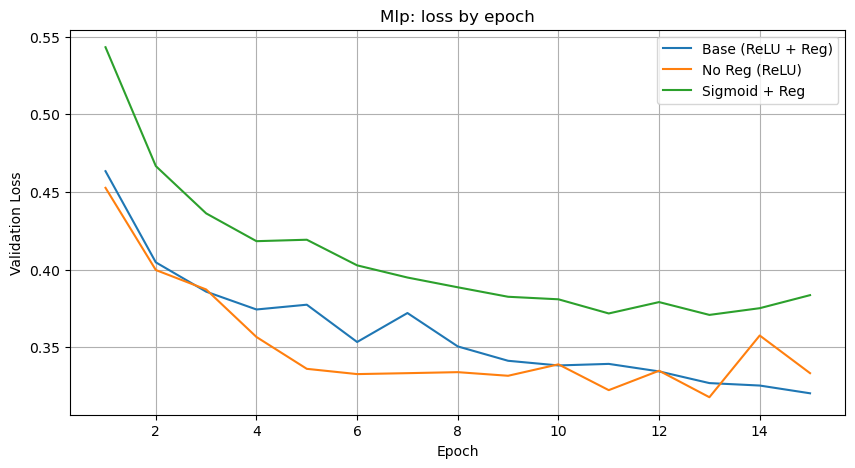

In [ ]:
epochs = np.arange(1, epochs_mlp + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, hist_base['val_loss'], label='Base (ReLU + Reg)')
plt.plot(epochs, hist_no_reg['val_loss'], label='No Reg (ReLU)')
plt.plot(epochs, hist_sigmoid['val_loss'], label='Sigmoid + Reg')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Mlp: loss by epoch')
plt.legend()
plt.grid(True)


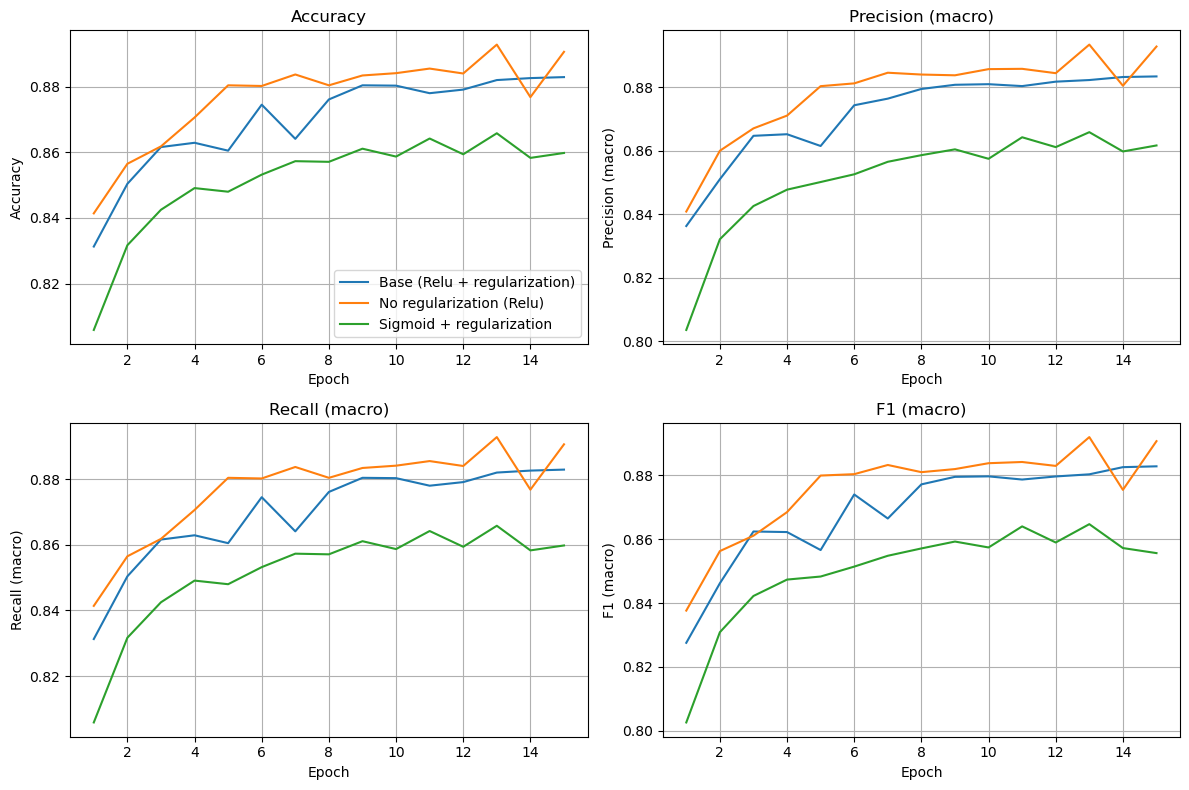

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics_map = [
    ('val_acc', 'Accuracy', axes[0, 0]),
    ('val_prec', 'Precision (macro)', axes[0, 1]),
    ('val_rec', 'Recall (macro)', axes[1, 0]),
    ('val_f1', 'F1 (macro)', axes[1, 1]),
]
for key, title, ax in metrics_map:
    ax.plot(epochs, hist_base[key], label='Base (Relu + regularization)')
    ax.plot(epochs, hist_no_reg[key], label='No regularization (Relu)')
    ax.plot(epochs, hist_sigmoid[key], label='Sigmoid + regularization')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.grid(True)
axes[0, 0].legend(loc='lower right')
plt.tight_layout()


In [ ]:
# финальные метрики
def final_row(name, hist):
    return {
        'model': name,
        'loss': round(hist['val_loss'][-1], 4),
        'accuracy': round(hist['val_acc'][-1], 4),
        'precision': round(hist['val_prec'][-1], 4),
        'recall': round(hist['val_rec'][-1], 4),
        'f1': round(hist['val_f1'][-1], 4),
    }

rows = [
    final_row('base (relu + regularization)', hist_base),
    final_row('no regularization (relu)', hist_no_reg),
    final_row('sigmoid + regularization', hist_sigmoid),
]

for r in rows:
    print(
        f"{r['model']}: "
        f"loss={r['loss']}, "
        f"acc={r['accuracy']}, "
        f"prec={r['precision']}, "
        f"rec={r['recall']}, "
        f"f1={r['f1']}"
    )


base (relu + regularization): loss=0.3203, acc=0.8829, prec=0.8833, rec=0.8829, f1=0.8829
no regularization (relu): loss=0.3333, acc=0.8906, prec=0.8928, rec=0.8906, f1=0.8908
sigmoid + regularization: loss=0.3835, acc=0.8598, prec=0.8616, rec=0.8598, f1=0.8557


In [ ]:
class SimpleCnn(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
# cnn
epochs_cnn = 10
cnn_model = SimpleCnn().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
hist_cnn = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_prec': [], 'val_prec': [],
    'train_rec': [], 'val_rec': [],
    'train_f1': [], 'val_f1': []
}
for epoch in range(epochs_cnn):
    tr = train_one_epoch(cnn_model, train_loader, criterion, optimizer)
    va = eval_one_epoch(cnn_model, test_loader, criterion)
    hist_cnn['train_loss'].append(tr[0]); hist_cnn['val_loss'].append(va[0])
    hist_cnn['train_acc'].append(tr[1]); hist_cnn['val_acc'].append(va[1])
    hist_cnn['train_prec'].append(tr[2]); hist_cnn['val_prec'].append(va[2])
    hist_cnn['train_rec'].append(tr[3]); hist_cnn['val_rec'].append(va[3])
    hist_cnn['train_f1'].append(tr[4]); hist_cnn['val_f1'].append(va[4])
    print(f"[cnn] epoch {epoch+1}/{epochs_cnn} | "
          f"train_loss={tr[0]:.4f} val_loss={va[0]:.4f} | "
          f"val_acc={va[1]:.4f} val_f1={va[4]:.4f}")


[cnn] epoch 1/10 | train_loss=0.5981 val_loss=0.4119 | val_acc=0.8540 val_f1=0.8534
[cnn] epoch 2/10 | train_loss=0.3634 val_loss=0.3501 | val_acc=0.8788 val_f1=0.8781
[cnn] epoch 3/10 | train_loss=0.3143 val_loss=0.3764 | val_acc=0.8647 val_f1=0.8653
[cnn] epoch 4/10 | train_loss=0.2820 val_loss=0.3038 | val_acc=0.8901 val_f1=0.8889
[cnn] epoch 5/10 | train_loss=0.2601 val_loss=0.3248 | val_acc=0.8821 val_f1=0.8815
[cnn] epoch 6/10 | train_loss=0.2431 val_loss=0.2808 | val_acc=0.8983 val_f1=0.8976
[cnn] epoch 7/10 | train_loss=0.2229 val_loss=0.2700 | val_acc=0.9018 val_f1=0.9015
[cnn] epoch 8/10 | train_loss=0.2109 val_loss=0.2701 | val_acc=0.9012 val_f1=0.8995
[cnn] epoch 9/10 | train_loss=0.1982 val_loss=0.2482 | val_acc=0.9091 val_f1=0.9098
[cnn] epoch 10/10 | train_loss=0.1880 val_loss=0.2600 | val_acc=0.9072 val_f1=0.9057


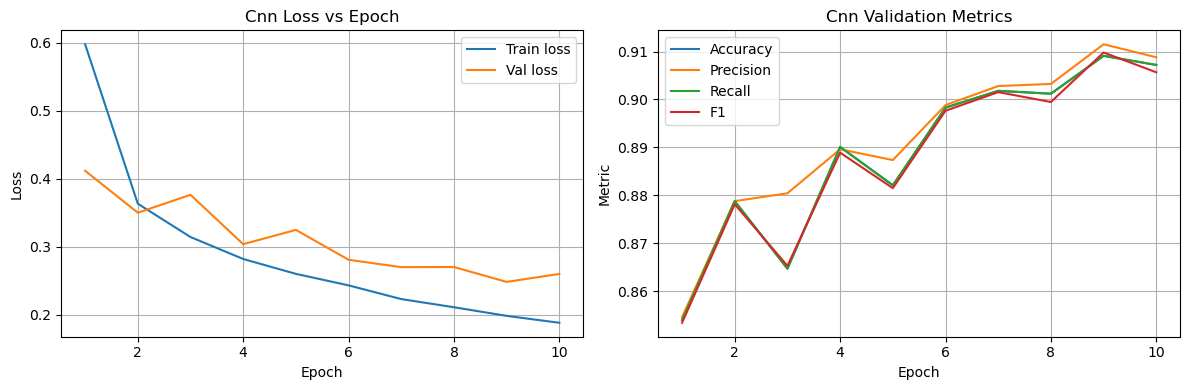

In [ ]:
epochs_cnn = np.arange(1, epochs_cnn + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_cnn, hist_cnn['train_loss'], label='Train loss')
axes[0].plot(epochs_cnn, hist_cnn['val_loss'], label='Val loss')
axes[0].set_title('Cnn Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)
axes[0].legend()
axes[1].plot(epochs_cnn, hist_cnn['val_acc'], label='Accuracy')
axes[1].plot(epochs_cnn, hist_cnn['val_prec'], label='Precision')
axes[1].plot(epochs_cnn, hist_cnn['val_rec'], label='Recall')
axes[1].plot(epochs_cnn, hist_cnn['val_f1'], label='F1')
axes[1].set_title('Cnn Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric')
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()


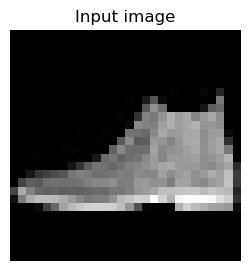

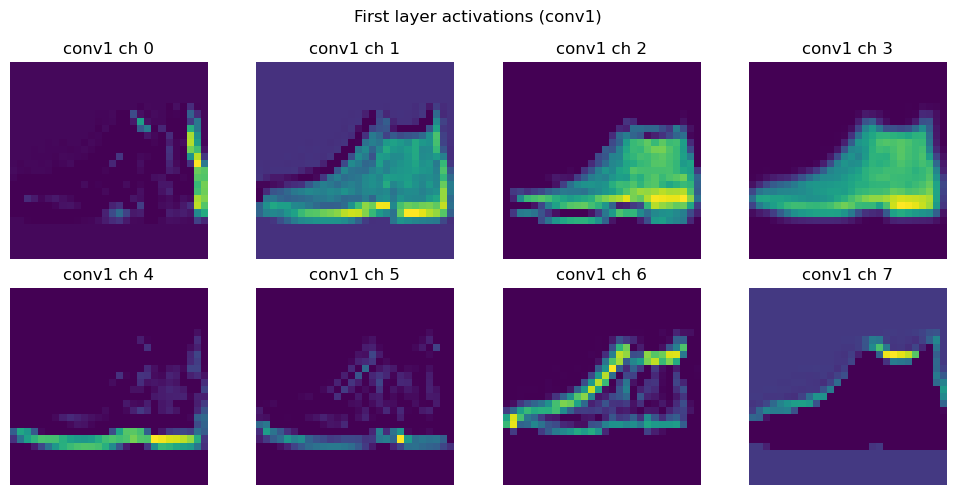

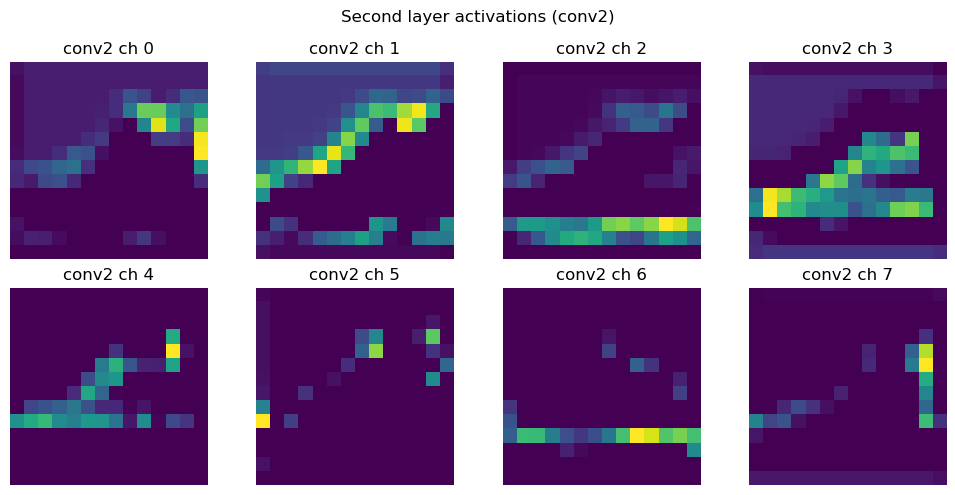

In [ ]:
cnn_model.eval()
sample_img, sample_label = test_dataset[0]
x = sample_img.unsqueeze(0).to(device)
with torch.no_grad():
    act1 = F.relu(cnn_model.conv1(x))
    pooled1 = cnn_model.pool(act1)
    act2 = F.relu(cnn_model.conv2(pooled1))
act1 = act1.squeeze(0).cpu()
act2 = act2.squeeze(0).cpu()
plt.figure(figsize=(3, 3))
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title('Input image')
plt.axis('off')
plt.show()
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(act1[i], cmap='viridis')
    ax.set_title(f'conv1 ch {i}')
    ax.axis('off')
plt.suptitle('First layer activations (conv1)')
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(act2[i], cmap='viridis')
    ax.set_title(f'conv2 ch {i}')
    ax.axis('off')
plt.suptitle('Second layer activations (conv2)')
plt.tight_layout()
plt.show()
